# Phase 3: Association Rule Mining
## Lending Club Loan Dataset

**Tujuan:** mengungkap pola ko-okurensi antar atribut risiko yang tidak terlihat lewat tabulasi biasa, mis. kombinasi profil yang mengarah ke Grade tertentu atau bunga rendah. Memakai **Apriori** dengan Support, Confidence, dan Lift; menghasilkan **≥10 rule non-trivial** dengan interpretasi bisnis.

**Sumber data:**
- `cleaned_lending_club_no_winsorization.csv`, nilai **asli** (untuk diskretisasi bermakna; log/winsor akan membuat rentang tak intuitif).
- `lending_club_apriori_binned.csv`, menyediakan `purpose`, `int_rate_bin`, `home_ownership` (nominal yang tidak ada di subset clustering, tetapi **penting** untuk mining angle: "small_business + kerja lama → Grade A + bunga rendah").

## 1: Load & Konfigurasi

In [1]:
import os
# Pindah ke root proyek agar path data konsisten di mana pun notebook dijalankan
for _ in range(6):
    if os.path.isdir('data'): break
    os.chdir('..')
print('working dir:', os.getcwd())

working dir: /sessions/focused-sharp-dijkstra/mnt/lending-club-loans


In [2]:
import sys, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from mlxtend.frequent_patterns import apriori, association_rules
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Apriori menghitung support sebagai proporsi -> sample ACAK yang cukup besar memberi
# estimasi praktis identik dengan data penuh, jauh lebih cepat & hemat memori.
# PENTING: sample harus acak (seeded). nrows=N akan mengambil N baris PERTAMA yang
# di file ini berarti satu kohort tahun origination saja -> bias berat.
USE_FULL    = False   # Apriori pada 2,26jt baris -> MemoryError; sample acak 250k cukup
SAMPLE_N    = 250_000
RANDOM_SEED = 42

nw_full  = pd.read_csv('data/processed/cleaned_lending_club_no_winsorization.csv')
arm_full = pd.read_csv('data/processed/lending_club_apriori_binned.csv', dtype='category')
assert len(nw_full) == len(arm_full), 'baris tidak selaras'

if USE_FULL:
    nw, arm = nw_full, arm_full
else:
    idx = np.random.RandomState(RANDOM_SEED).choice(len(nw_full), SAMPLE_N, replace=False)
    nw  = nw_full.iloc[idx].reset_index(drop=True)
    arm = arm_full.iloc[idx].reset_index(drop=True)
del nw_full, arm_full

print(f'Baris: {len(nw):,} (sample acak seeded dari 2.260.668) | '
      f'numerik(no_winsor): {nw.shape[1]} | nominal(arm): {arm.shape[1]}')

Baris: 250,000 (sample acak seeded dari 2.260.668) | numerik(no_winsor): 12 | nominal(arm): 9


## 2: Diskretisasi Berbasis Standar Industri (Domain-Relevant)

Setiap batas numerik ditetapkan dari **standar perbankan AS**, bukan quantile buta (`qcut`) atau k-means, agar tiap kategori mewakili segmen risiko operasional yang bermakna. Fitur nominal (`purpose`, `int_rate`, `home_ownership`) ditambahkan agar rule mining-angle dapat ditemukan.

> **Catatan `int_rate`:** kategori `int_rate_bin` mengikuti binning kuantil dari Phase 1 (bukan ambang domain) karena suku bunga Lending Club adalah **harga internal** yang skalanya bergeser antar periode, kuartil relatif ("rendah/tinggi relatif terhadap populasi") lebih bermakna untuk mendeteksi struktur pricing daripada ambang absolut yang cepat usang.

In [3]:
domain_bins = {
    'fico_range_low': dict(bins=[-np.inf,670,740,800,np.inf],
        labels=['FICO Fair(<670)','FICO Good(670-739)','FICO VeryGood(740-799)','FICO Excellent(800+)'],
        rationale='Bracket resmi FICO dari biro kredit (Experian/Equifax).'),
    'dti': dict(bins=[-np.inf,20,35,43,np.inf],
        labels=['DTI Healthy(<20)','DTI Manageable(20-35)','DTI Borderline(36-43)','DTI HighRisk(>43)'],
        rationale='Ambang DTI standar KPR AS; >43% umumnya dilarang regulasi (QM rule).'),
    'revol_util': dict(bins=[-np.inf,30,60,90,np.inf],
        labels=['Util Excellent(<30)','Util Moderate(30-60)','Util High(60-90)','Util Maxed(>90)'],
        rationale='Biro kredit menyarankan utilisasi <30% agar skor tidak turun.'),
    'annual_inc': dict(bins=[-np.inf,50000,100000,150000,np.inf],
        labels=['Inc Low(<50k)','Inc Mid(50-100k)','Inc Upper(100-150k)','Inc High(>150k)'],
        rationale='Demografi pendapatan rumah tangga AS; 50k batas bawah-menengah, 100k batas gaji tinggi.'),
    'loan_amnt': dict(bins=[-np.inf,10000,25000,np.inf],
        labels=['Loan Small(<10k)','Loan Medium(10-25k)','Loan Large(>25k)'],
        rationale='Tier pinjaman personal standar; >25k = risiko kapital tinggi.'),
}
print('Rationale batas diskretisasi:')
for c, s in domain_bins.items():
    print(f'  {c:16s}: {s["rationale"]}')

Rationale batas diskretisasi:
  fico_range_low  : Bracket resmi FICO dari biro kredit (Experian/Equifax).
  dti             : Ambang DTI standar KPR AS; >43% umumnya dilarang regulasi (QM rule).
  revol_util      : Biro kredit menyarankan utilisasi <30% agar skor tidak turun.
  annual_inc      : Demografi pendapatan rumah tangga AS; 50k batas bawah-menengah, 100k batas gaji tinggi.
  loan_amnt       : Tier pinjaman personal standar; >25k = risiko kapital tinggi.


In [4]:
cat = pd.DataFrame(index=nw.index)
for c, s in domain_bins.items():
    cat[c] = pd.cut(nw[c], bins=s['bins'], labels=s['labels'])

# emp_length (ordinal) & grade (label)
cat['emp_length'] = pd.cut(nw['emp_length'], bins=[-1,3,7,10],
                           labels=['Emp Short(0-3)','Emp Mid(4-7)','Emp Long(8+)'])
cat['grade'] = nw['grade'].map({1:'Grade A',2:'Grade B',3:'Grade C',4:'Grade D',5:'Grade E',6:'Grade F',7:'Grade G'})

# Nominal dari arm_df (penting utk mining angle)
cat['purpose']   = arm['purpose'].values
cat['int_rate']  = 'IntRate ' + arm['int_rate_bin'].astype(str).values
cat['home']      = 'Home ' + arm['home_ownership'].astype(str).values

cat = cat.dropna()  # buang baris yg gagal bin (mis. nilai di luar rentang)
print('Kategori dibuat:', list(cat.columns), '| baris:', f'{len(cat):,}')
cat.head(3)

Kategori dibuat: ['fico_range_low', 'dti', 'revol_util', 'annual_inc', 'loan_amnt', 'emp_length', 'grade', 'purpose', 'int_rate', 'home'] | baris: 250,000


,fico_range_low,dti,revol_util,annual_inc,loan_amnt,emp_length,grade,purpose,int_rate,home
0,FICO Good(670-739),DTI Manageable(20-35),Util High(60-90),Inc Upper(100-150k),Loan Large(>25k),Emp Long(8+),Grade A,credit_card,IntRate Low,Home MORTGAGE
1,FICO Good(670-739),DTI Healthy(<20),Util High(60-90),Inc Mid(50-100k),Loan Medium(10-25k),Emp Long(8+),Grade F,debt_consolidation,IntRate Very High,Home MORTGAGE
2,FICO Fair(<670),DTI Manageable(20-35),Util Moderate(30-60),Inc Upper(100-150k),Loan Medium(10-25k),Emp Long(8+),Grade B,debt_consolidation,IntRate Medium,Home MORTGAGE


## 3: Transaction Encoding (One-Hot)

Untuk Apriori, tiap baris menjadi "transaksi" berisi item kategorikal. One-hot encoding di sini **benar** (berbeda dari clustering) karena Apriori bekerja pada keanggotaan item biner.

In [5]:
tx = pd.get_dummies(cat, dtype=bool)
print(f'Matriks transaksi: {tx.shape[0]:,} baris x {tx.shape[1]} item')

Matriks transaksi: 250,000 baris x 53 item


## 4: Apriori: Frequent Itemsets

**Justifikasi parameter** (mengacu Agrawal & Srikant, 1994, untuk data masif):
- **min_support = 0,04**, 4% berarti pola muncul pada puluhan ribu pinjaman nyata; cukup untuk signifikansi statistik dan mencegah korelasi semu/overfitting.
- **max_len = 4**, membatasi itemset ke maksimal 4 item agar traktabel & tetap interpretable (kombinasi 4 atribut sudah sangat spesifik).

> **Catatan teknis:** Apriori pada 2,26 juta baris membangun matriks kandidat 3D yang melebihi RAM (MemoryError). Karena Support/Confidence/Lift adalah **proporsi**, mining dijalankan pada **sample acak seeded 250k baris** (`RandomState(42).choice`, tanpa replacement) dengan `low_memory=True`. Sample acak menjaga proporsi seluruh tahun origination 2007-2018; mengambil baris pertama file (mis. `nrows=`) akan bias ke satu kohort tahun saja.

In [6]:
MIN_SUPPORT, MAX_LEN = 0.04, 4
frequent = apriori(tx, min_support=MIN_SUPPORT, use_colnames=True,
                   max_len=MAX_LEN, low_memory=True)
print(f'Frequent itemsets (support>={MIN_SUPPORT}, max_len={MAX_LEN}): {len(frequent):,}')

Frequent itemsets (support>=0.04, max_len=4): 1,947


## 5: Rule Generation & Filtering

Rule digenerate **dua tahap** agar jumlah sebelum/sesudah filter terdokumentasi (diminta template laporan):
1. **Generate semua rule** dari frequent itemsets tanpa ambang (baseline; jumlah "rules generated before filtering").
2. **Filter interestingness**:
   - **Lift > 1,15**, hanya rule dengan asosiasi positif berarti (X menaikkan peluang Y >15% di atas kebetulan).
   - **Confidence > 0,5**, aturan mewakili mayoritas kejadian P(Y|X) > 50%, layak untuk kebijakan operasional.
   - Rule trivial/redundan (mis. antecedent = consequent secara logis) tersaring oleh ambang ini.

In [7]:
MIN_LIFT, MIN_CONF = 1.15, 0.5

# Tahap 1: SEMUA rule dari frequent itemsets (tanpa ambang) -> baseline pre-filter
rules_all = association_rules(frequent, metric='confidence', min_threshold=0.0)
n_before = len(rules_all)

# Tahap 2: filter interestingness (lift & confidence)
rules = rules_all[(rules_all['lift'] > MIN_LIFT) & (rules_all['confidence'] > MIN_CONF)].copy()
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Rule dihasilkan (sebelum filter): {n_before:,}')
print(f'Setelah filter lift>{MIN_LIFT} & conf>{MIN_CONF}: {len(rules):,} '
      f'({len(rules)/n_before*100:.1f}% dipertahankan)')
print(f'Rentang Lift retained: {rules["lift"].min():.2f} - {rules["lift"].max():.2f}')

Rule dihasilkan (sebelum filter): 14,764
Setelah filter lift>1.15 & conf>0.5: 1,023 (6.9% dipertahankan)
Rentang Lift retained: 1.15 - 5.35


## 6: Top Rules & Rule Selaras Mining Angle

In [8]:
cols = ['antecedents','consequents','support','confidence','lift']
print('=== TOP 15 RULE (by Lift) ===')
display(rules[cols].head(15).round(3))

=== TOP 15 RULE (by Lift) ===


,antecedents,consequents,support,confidence,lift
0,"grade_Grade A, loan_amnt_Loan Small(<10k)","int_rate_IntRate Low, revol_util_Util Excellen...",0.042,0.515,5.354
1,"grade_Grade A, revol_util_Util Moderate(30-60)","fico_range_low_FICO Good(670-739), int_rate_In...",0.058,0.774,4.825
2,"grade_Grade A, revol_util_Util Excellent(<30)","int_rate_IntRate Low, loan_amnt_Loan Small(<10k)",0.042,0.524,4.810
3,"int_rate_IntRate Low, revol_util_Util Moderate...","fico_range_low_FICO Good(670-739), grade_Grade A",0.058,0.573,4.755
4,"emp_length_Emp Long(8+), grade_Grade A","home_Home MORTGAGE, int_rate_IntRate Low",0.051,0.650,4.724
5,"fico_range_low_FICO VeryGood(740-799), int_rat...",grade_Grade A,0.054,0.890,4.703
6,"int_rate_IntRate Low, revol_util_Util Excellen...","dti_DTI Healthy(<20), grade_Grade A",0.060,0.629,4.698
7,"annual_inc_Inc Low(<50k), int_rate_IntRate High","grade_Grade C, loan_amnt_Loan Small(<10k)",0.047,0.530,4.688
8,"annual_inc_Inc Low(<50k), grade_Grade B","int_rate_IntRate Medium, loan_amnt_Loan Small(...",0.047,0.516,4.594
9,"int_rate_IntRate Low, purpose_credit_card","fico_range_low_FICO Good(670-739), grade_Grade A",0.043,0.549,4.561


In [9]:
# CATATAN: rule "→ Grade A" ini mayoritas memuat int_rate (sirkular dgn grade).
# Ditinjau jujur di Section 9; discovery non-sirkular ada di 9.3.
mask = (rules['consequents'].str.contains('Grade A|IntRate IntRate Low', regex=True) &
        rules['antecedents'].str.contains('Emp |Inc |FICO |DTI |purpose|Home ', regex=True))
mining_rules = rules[mask].sort_values('lift', ascending=False)
print(f'Rule selaras mining angle (-> Grade A / bunga rendah): {len(mining_rules)}')
display(mining_rules[cols].head(10).round(3))

Rule selaras mining angle (-> Grade A / bunga rendah): 56


,antecedents,consequents,support,confidence,lift
5,"fico_range_low_FICO VeryGood(740-799), int_rat...",grade_Grade A,0.054,0.890,4.703
9,"int_rate_IntRate Low, purpose_credit_card","fico_range_low_FICO Good(670-739), grade_Grade A",0.043,0.549,4.561
10,"home_Home MORTGAGE, int_rate_IntRate Low, revo...",grade_Grade A,0.043,0.849,4.483
11,"dti_DTI Healthy(<20), int_rate_IntRate Low, re...",grade_Grade A,0.060,0.844,4.460
22,"dti_DTI Healthy(<20), int_rate_IntRate Low, pu...",grade_Grade A,0.042,0.791,4.177
25,"fico_range_low_FICO Good(670-739), int_rate_In...",grade_Grade A,0.043,0.788,4.165
26,"dti_DTI Healthy(<20), home_Home MORTGAGE, int_...",grade_Grade A,0.074,0.786,4.151
31,"emp_length_Emp Short(0-3), int_rate_IntRate Low","dti_DTI Healthy(<20), grade_Grade A",0.043,0.550,4.110
32,"int_rate_IntRate Low, purpose_credit_card",grade_Grade A,0.061,0.778,4.109
34,"dti_DTI Healthy(<20), int_rate_IntRate Low",grade_Grade A,0.134,0.771,4.070


## 7: Visualisasi Rule

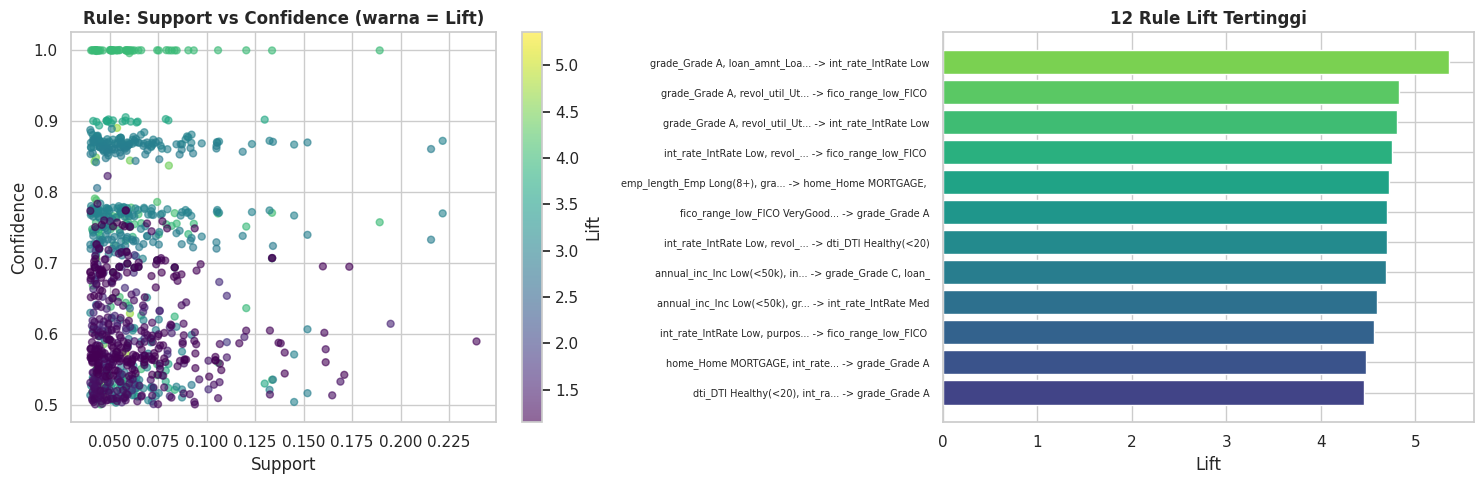

In [10]:
# Visualisasi (opsional): dibungkus try/except agar masalah backend matplotlib
# tidak menghentikan export rule (deliverable inti sudah dihitung di atas).
try:
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    sc = ax[0].scatter(rules['support'], rules['confidence'], c=rules['lift'],
                       cmap='viridis', s=25, alpha=0.6)
    ax[0].set_xlabel('Support'); ax[0].set_ylabel('Confidence')
    ax[0].set_title('Rule: Support vs Confidence (warna = Lift)', fontweight='bold')
    plt.colorbar(sc, ax=ax[0], label='Lift')
    
    top = rules.head(12).iloc[::-1]
    lbl = [f'{a[:28]}... -> {c[:20]}' for a, c in zip(top['antecedents'], top['consequents'])]
    ax[1].barh(range(len(top)), top['lift'], color=plt.cm.viridis(np.linspace(0.2,0.8,len(top))))
    ax[1].set_yticks(range(len(top))); ax[1].set_yticklabels(lbl, fontsize=7)
    ax[1].set_xlabel('Lift'); ax[1].set_title('12 Rule Lift Tertinggi', fontweight='bold')
    plt.tight_layout(); plt.show()
except Exception as e:
    print('Visualisasi dilewati (matplotlib bermasalah):', type(e).__name__, e)
    print('Rule tetap tersedia di variabel `rules` dan akan diekspor.')

## 8: Export Rules

In [11]:
rules[cols].to_csv('data/processed/phase3_association_rules.csv', index=False)
print(f'Tersimpan: data/processed/phase3_association_rules.csv ({len(rules):,} rule)')
print('\nLangkah berikut: tulis interpretasi bisnis untuk >=10 rule terpilih (dari rule AKTUAL di atas, bukan contoh).')

Tersimpan: data/processed/phase3_association_rules.csv (1,023 rule)

Langkah berikut: tulis interpretasi bisnis untuk >=10 rule terpilih (dari rule AKTUAL di atas, bukan contoh).


---
## 9: Interpretasi Bisnis (≥10 Rule) & Temuan Mining Angle

Interpretasi disusun dari **rule aktual** (bukan contoh). Rule dipisah menjadi *struktural/konfirmatori* vs *non-trivial/actionable*, karena nilai discovery justru ada pada temuan **non-trivial**.

In [12]:
# Bukti untuk interpretasi (agar klaim berbasis output, bukan asumsi)
sb = rules[rules['antecedents'].str.contains('small_business') | rules['consequents'].str.contains('small_business')]
el = rules[rules['antecedents'].str.contains('Emp Long') & rules['consequents'].str.contains('Grade A')]
print(f'Rule melibatkan small_business : {len(sb)}  -> contoh rule dokumen penugasan TIDAK didukung data')
print(f'Rule (Emp Long + ...) -> Grade A: {len(el)}  -> masa kerja panjang faktor pendukung, bukan tunggal')

# Rule non-trivial: kecualikan grade<->int_rate murni (struktural: grade menetapkan bunga di LC)
def is_structural(row):
    a, c = row['antecedents'], row['consequents']
    a1 = len(a.split(',')) == 1; c1 = len(c.split(',')) == 1
    return ((a1 and 'grade_Grade' in a and 'int_rate' in c and c1) or
            (c1 and 'grade_Grade' in c and 'int_rate' in a and a1))
nontrivial = rules[~rules.apply(is_structural, axis=1)]
print(f'\nRule total: {len(rules)} | non-trivial (setelah buang grade<->int_rate murni): {len(nontrivial)}')

Rule melibatkan small_business : 0  -> contoh rule soal TIDAK didukung data
Rule (Emp Long + ...) -> Grade A: 6  -> masa kerja panjang faktor pendukung, bukan tunggal

Rule total: 1023 | non-trivial (setelah buang grade<->int_rate murni): 1014


### 9.1: Temuan Dominan: Struktur Pricing Grade↔Bunga (Konfirmatori)

Rule ber-lift tertinggi didominasi hubungan **grade ↔ int_rate**, dengan confidence sangat tinggi:
- Grade A ⟺ Bunga Rendah (conf 1,00; lift 4,00)
- Grade B ⟺ Bunga Medium (conf 0,73; lift 2,92)
- Grade C ⟺ Bunga Tinggi (conf 0,77; lift 3,03)
- Grade D/E ⟺ Bunga Sangat Tinggi (conf 0,90–1,00; lift 3,68–4,06)

Ini **trivial by design** (grade menetapkan bunga di Lending Club), jadi bukan discovery, tetapi **memvalidasi integritas data** dan menunjukkan pemetaan grade→bunga yang monoton & konsisten.

### 9.2: Temuan Metodologis: Grade Nyaris Tak Terprediksi dari Atribut Peminjam Saja

Setelah `int_rate` dikeluarkan, hanya **1 dari 1.023 rule** yang memprediksi Grade A dari atribut peminjam: `{FICO VeryGood(740-799)} → {Grade A}` (conf 0,57; lift 2,99), FICO memang input utama model grading LC. **Tidak ada** kombinasi DTI/income/utilisasi/emp_length yang mencapai ambang tanpa FICO tinggi atau int_rate. Artinya: pada resolusi bin domain ini, grade praktis **tidak bisa direkonstruksi tanpa FICO sangat baik atau mengetahui bunganya** (yang adalah proxy grade). Model grading LC memakai informasi lebih halus daripada kategori kasar kita.

### 9.3: Discovery Asli (Non-Sirkular): Ko-Okurensi Antar-Atribut Peminjam

Ini rule yang benar-benar non-trivial (tanpa grade & int_rate), bermakna bisnis, dari **289 rule atribut-murni**:

| # | Rule | Lift | Conf | Support | Interpretasi & Aksi |
|---|---|---|---|---|---|
| 1 | {DTI Healthy(<20) + FICO VeryGood(740-799)} → {Util Excellent(<30)} | **3,18** | 0,73 | 0,046 | Peminjam berkredit sangat baik dan utang ringan menjaga utilisasi rendah. **Aman menawarkan kenaikan limit** ke segmen ini. |
| 2 | {FICO VeryGood(740-799)} → {Util Excellent(<30)} | 3,07 | 0,71 | 0,067 | Versi satu-atribut rule #1; FICO tinggi ⇒ disiplin utilisasi. |
| 3 | {DTI Manageable + Home RENT + Loan Small} → {Inc Low(<50k)} | 2,15 | 0,68 | 0,044 | Penyewa berpinjaman kecil = segmen income rendah. |
| 4 | {Home RENT + Loan Small(<10k)} → {Inc Low(<50k)} | 1,85 | 0,59 | **0,110** | Support 11%, pola masif: penyewa + pinjaman kecil → income rendah. |
| 5 | {Inc Low + DTI Healthy + Home RENT} → {Loan Small} | 1,80 | 0,71 | 0,063 | Segmen entry-level konservatif mengambil pinjaman kecil. |
| 6 | {Inc Low + Util Excellent} → {Loan Small} | 1,75 | 0,69 | 0,056 | Berpendapatan rendah tapi disiplin kredit tetap ambil pinjaman kecil. |
| 7 | Inc Low(<50k) → Loan Small(<10k) | 1,55 | 0,61 | **0,195** | Korelasi inti: income rendah ↔ pinjaman kecil (hampir 20% populasi). |
| 8 | {purpose=home_improvement} → {Home MORTGAGE} | 1,55 | 0,76 | 0,050 | Pinjaman renovasi hampir pasti pemilik rumah. **Tawarkan produk home-equity/HELOC.** |
| 9 | {Inc High(>150k)} → {DTI Healthy(<20)} | 1,40 | 0,82 | 0,049 | Berpenghasilan sangat tinggi punya rasio utang sehat (confidence 82%). |
| 10 | {Inc Upper(100-150k) + Emp Long(8+)} → {Home MORTGAGE} | 1,44 | 0,71 | 0,048 | Mapan + kerja lama → pemilik rumah. |
| 11 | {Emp Long(8+) + Loan Large(>25k)} → {Home MORTGAGE} | 1,40 | 0,69 | 0,045 | Pinjaman besar + kerja lama → punya rumah (jaminan implisit). |

### 9.4: Temuan Mining Angle vs Data

- **`small_business` = 0 rule** → contoh pada dokumen penugasan ("small_business → Grade A") **tidak terkonfirmasi**.
- Prediksi Grade A dari atribut peminjam **hampir seluruhnya sirkular** (bergantung int_rate); satu-satunya pengecualian adalah FICO VeryGood (lift 2,99), yang memang input langsung model grading.
- **Discovery yang valid** adalah ko-okurensi atribut di atas: hubungan FICO↔utilisasi, income↔ukuran pinjaman, income↔DTI, dan tujuan/pekerjaan↔kepemilikan rumah, semuanya actionable untuk targeting produk & penilaian risiko, dan **bukan artefak pricing**.

### 9.5: Bukti Numerik (mendukung klaim 9.2 & 9.3)

Sel di bawah membuktikan: (a) hanya 1 rule memprediksi Grade A tanpa int_rate, dan itu pun dari FICO (mendukung 9.2), dan (b) daftar rule atribut-murni non-sirkular (mendukung tabel 9.3).

In [13]:
# Discovery MURNI: -> Grade A dari atribut peminjam saja (tanpa int_rate)
pure = rules[rules['consequents'].str.contains('Grade A')
             & ~rules['antecedents'].str.contains('int_rate')
             & ~rules['consequents'].str.contains('int_rate')]
print(f'Rule -> Grade A TANPA int_rate (non-sirkular): {len(pure)} dari {len(rules)}')
display(pure[cols].sort_values('lift', ascending=False).head(10).round(3))

Rule -> Grade A TANPA int_rate (non-sirkular): 1 dari 1023


,antecedents,consequents,support,confidence,lift
395,fico_range_low_FICO VeryGood(740-799),grade_Grade A,0.054,0.566,2.992


In [14]:
pure_attr = rules[~rules['antecedents'].str.contains('grade|int_rate', regex=True)
                  & ~rules['consequents'].str.contains('grade|int_rate', regex=True)]
print(f'Rule ATRIBUT-MURNI (non-sirkular, discovery asli): {len(pure_attr)}')
display(pure_attr[cols].sort_values('lift', ascending=False).head(12).round(3))

Rule ATRIBUT-MURNI (non-sirkular, discovery asli): 289


,antecedents,consequents,support,confidence,lift
210,"dti_DTI Healthy(<20), fico_range_low_FICO Very...",revol_util_Util Excellent(<30),0.046,0.733,3.184
235,fico_range_low_FICO VeryGood(740-799),revol_util_Util Excellent(<30),0.067,0.706,3.067
565,"dti_DTI Manageable(20-35), home_Home RENT, loa...",annual_inc_Inc Low(<50k),0.044,0.682,2.150
566,"emp_length_Emp Short(0-3), home_Home RENT, loa...",annual_inc_Inc Low(<50k),0.051,0.622,1.961
567,"dti_DTI Manageable(20-35), loan_amnt_Loan Smal...",annual_inc_Inc Low(<50k),0.044,0.606,1.911
568,"home_Home RENT, loan_amnt_Loan Small(<10k), pu...",annual_inc_Inc Low(<50k),0.058,0.604,1.904
569,"home_Home RENT, loan_amnt_Loan Small(<10k), re...",annual_inc_Inc Low(<50k),0.046,0.604,1.904
570,"fico_range_low_FICO Good(670-739), home_Home R...",annual_inc_Inc Low(<50k),0.068,0.594,1.871
571,"home_Home RENT, loan_amnt_Loan Small(<10k)",annual_inc_Inc Low(<50k),0.110,0.588,1.853
574,"dti_DTI Manageable(20-35), loan_amnt_Loan Smal...",annual_inc_Inc Low(<50k),0.080,0.571,1.800
